In [6]:
"""
RANDOM FOREST MODEL - EXACTLY AS PER PAPER
Paper parameters (Table 7):
- n_estimators: 100 (default)
- max_depth: None (no maximum depth)
- random_state: 0 (as per paper)
"""

# ==================== IMPORTS ====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_curve, roc_auc_score, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

# Set random seed to match paper's "random state of 0"
np.random.seed(0)

print("✅ Imports completed successfully")
print("✅ Random seed set to 0")

✅ Imports completed successfully
✅ Random seed set to 0


In [7]:

print("RANDOM FOREST MODEL")

print("\n[1] Loading dataset...")
try:
    
    df = pd.read_csv(r"C:\Rainproj\rain.csv") 
    print(f"✓ Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
    display(df.head(3))
except FileNotFoundError:
    print("❌ Dataset not found! Please check the file path.")
    # Try alternative paths
    try:
        df = pd.read_csv() 
        print(f"✓ Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
    except:
        print("Please update the file path to your dataset")

RANDOM FOREST MODEL - EXACT PAPER IMPLEMENTATION

[1] Loading dataset...
✓ Loaded: 145,460 rows, 23 columns


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No


In [8]:
# PREPROCESSING
print("\n[2] Preprocessing data...")


df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df.drop('Date', axis=1, inplace=True)

original_shape = df.shape
df_clean = df.dropna()
print(f"  • Original shape: {original_shape[0]:,} rows")
print(f"  • After dropping NA: {df_clean.shape[0]:,} rows")
print(f"  • Rows removed: {original_shape[0] - df_clean.shape[0]:,}")


categorical_cols = df_clean.select_dtypes(include=['object','string']).columns.tolist()
categorical_cols.remove('RainTomorrow')
print(f"  • Categorical columns: {categorical_cols}")

df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
df_encoded['RainTomorrow'] = df_encoded['RainTomorrow'].map({'Yes': 1, 'No': 0})

print(f"  • Features after encoding: {df_encoded.shape[1]-1}")
print(f"  • Class distribution: {df_encoded['RainTomorrow'].mean():.2%} positive")


[2] Preprocessing data...
  • Original shape: 145,460 rows
  • After dropping NA: 56,420 rows
  • Rows removed: 89,040
  • Categorical columns: ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']
  • Features after encoding: 88
  • Class distribution: 22.03% positive


In [9]:
# ==================== TRAIN-TEST SPLIT ==================
X = df_encoded.drop('RainTomorrow', axis=1)
y = df_encoded['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n[3] Data split:")
print(f"  • Training: {X_train.shape[0]:,} samples")
print(f"  • Testing:  {X_test.shape[0]:,} samples")
print(f"  • Features: {X_train.shape[1]}")


[3] Data split:
  • Training: 45,136 samples
  • Testing:  11,284 samples
  • Features: 88


In [10]:
# ==================== QUANTILE TRANSFORMATION ====================
print("\n[4] Applying quantile transformation...")
quantile_transformer = QuantileTransformer(output_distribution='uniform', random_state=42)
X_train_transformed = quantile_transformer.fit_transform(X_train)
X_test_transformed = quantile_transformer.transform(X_test)

X_train_transformed = pd.DataFrame(X_train_transformed, columns=X_train.columns)
X_test_transformed = pd.DataFrame(X_test_transformed, columns=X_test.columns)
print("  ✓ Transformation complete")



[4] Applying quantile transformation...
  ✓ Transformation complete
  • Transformed data range: [0.00, 1.00]


In [11]:
# ==================== FEATURE SELECTION ====================
print("\n[5] Performing feature selection...")

dt_selector = DecisionTreeClassifier(random_state=42)
dt_selector.fit(X_train_transformed, y_train)

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': dt_selector.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("\nTop 10 features ")
print("-" * 80)
for i in range(10):
    print(f"{i+1:2d}. {feature_importance.loc[i, 'feature'][:50]:50} {feature_importance.loc[i, 'importance']:.6f}")


paper_features = []
for feature in ['Humidity3pm','Sunshine', 'Humidity9am','Rainfall','Cloud9am', 'Cloud3pm','RainToday']:
    matches = [col for col in X_train.columns if feature in col]
    paper_features.extend(matches)


if len(paper_features) >= 5:
    selected_features = paper_features[:5]
    print(f"\n  Using paper's specified features: {selected_features}")
else:
    selected_features = feature_importance.head(5)['feature'].tolist()
    print(f"\n   Using top 5 features: {selected_features}")

X_train_selected = X_train_transformed[selected_features]
X_test_selected = X_test_transformed[selected_features]
print(f"  • Selected features shape: {X_train_selected.shape}")


[5] Performing feature selection...

Top 10 features (as per paper Figure 20):
--------------------------------------------------------------------------------
 1. Humidity3pm                                        0.273377
 2. Sunshine                                           0.089600
 3. Pressure3pm                                        0.075924
 4. WindGustSpeed                                      0.052341
 5. Humidity9am                                        0.035647
 6. Pressure9am                                        0.035053
 7. MinTemp                                            0.032109
 8. Rainfall                                           0.029867
 9. Temp9am                                            0.028968
10. Evaporation                                        0.028800

  ✓ Using paper's specified features: ['Humidity3pm', 'Sunshine', 'Humidity9am', 'Rainfall', 'Cloud9am']
  • Selected features shape: (45136, 5)


In [12]:
# ==================== PART 1: BEFORE FEATURE SELECTION ====================
print("\n" + "="*60)
print("PART 1: RANDOM FOREST - BEFORE FEATURE SELECTION")
print("="*60)

# EXACT parameters from paper Table 7:
# - No max depth (None)
# - random_state = 0 (paper says "random state of 0")
rf_before = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,  # As per paper
    random_state=0,  # As per paper
    n_jobs=-1
)

print("\nTraining Random Forest on ALL features...")
%time rf_before.fit(X_train_transformed, y_train)

# Predictions
y_pred_before = rf_before.predict(X_test_transformed)
y_pred_proba_before = rf_before.predict_proba(X_test_transformed)[:, 1]

# Calculate metrics
accuracy_before = accuracy_score(y_test, y_pred_before)
precision_before = precision_score(y_test, y_pred_before)
recall_before = recall_score(y_test, y_pred_before)
f1_before = f1_score(y_test, y_pred_before)
auc_before = roc_auc_score(y_test, y_pred_proba_before)

# Confusion Matrix and G-mean
cm_before = confusion_matrix(y_test, y_pred_before)
tn, fp, fn, tp = cm_before.ravel()
gmean_before = np.sqrt((tp/(tp+fn)) * (tn/(tn+fp)))

print("\n" + "-"*60)
print("RESULTS - BEFORE FEATURE SELECTION")
print("-"*60)
print(f"{'Metric':<12} {'Our Result':<12} {'Paper':<12} {'Difference':<12}")
print("-"*60)
print(f"{'Accuracy':<12} {accuracy_before:.4f}       {0.85:<12} {abs(accuracy_before-0.85):.4f}")
print(f"{'Precision':<12} {precision_before:.4f}       {0.82:<12} {abs(precision_before-0.82):.4f}")
print(f"{'Recall':<12} {recall_before:.4f}       {0.74:<12} {abs(recall_before-0.74):.4f}")
print(f"{'F1-Score':<12} {f1_before:.4f}       {0.74:<12} {abs(f1_before-0.74):.4f}")
print(f"{'G-mean':<12} {gmean_before:.4f}       {0.69:<12} {abs(gmean_before-0.69):.4f}")
print(f"{'AUC-ROC':<12} {auc_before:.4f}       {0.70:<12} {abs(auc_before-0.70):.4f}")
print("-"*60)

print(f"\nConfusion Matrix (Before FS):")
print(f"TN: {tn:6d}  FP: {fp:6d}")
print(f"FN: {fn:6d}  TP: {tp:6d}")


PART 1: RANDOM FOREST - BEFORE FEATURE SELECTION

Training Random Forest on ALL features...
CPU times: total: 16.3 s
Wall time: 1.76 s

------------------------------------------------------------
RESULTS - BEFORE FEATURE SELECTION
------------------------------------------------------------
Metric       Our Result   Paper        Difference  
------------------------------------------------------------
Accuracy     0.8654       0.85         0.0154
Precision    0.7892       0.82         0.0308
Recall       0.5304       0.74         0.2096
F1-Score     0.6344       0.74         0.1056
G-mean       0.7136       0.69         0.0236
AUC-ROC      0.8973       0.7          0.1973
------------------------------------------------------------

Confusion Matrix (Before FS):
TN:   8447  FP:    352
FN:   1167  TP:   1318


In [13]:
# ==================== 10-FOLD CROSS-VALIDATION (AS PER PAPER SECTION III-F) ====================
print("\n" + "="*60)
print("10-FOLD CROSS-VALIDATION")
print("="*60)

from sklearn.model_selection import cross_val_score, StratifiedKFold

# 10-fold cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Before FS
cv_scores_before = cross_val_score(rf_before, X_train_transformed, y_train, 
                                   cv=cv, scoring='accuracy', n_jobs=-1)
print("\nBefore Feature Selection - 10-Fold CV:")
print(f"  • Fold scores: {cv_scores_before}")
print(f"  • Mean accuracy: {cv_scores_before.mean():.4f} (+/- {cv_scores_before.std()*2:.4f})")
print(f"  • Test accuracy: {accuracy_before:.4f}")
print(f"  • Difference (CV vs Test): {abs(cv_scores_before.mean() - accuracy_before):.4f}")

# After FS (will run after Cell 8)


10-FOLD CROSS-VALIDATION (AS MENTIONED IN PAPER SECTION III-F)

Before Feature Selection - 10-Fold CV:
  • Fold scores: [0.85423128 0.85999114 0.85932654 0.86996012 0.85976961 0.85866194
 0.86527809 0.86527809 0.86040328 0.86771549]
  • Mean accuracy: 0.8621 (+/- 0.0091)
  • Test accuracy: 0.8654
  • Difference (CV vs Test): 0.0033


In [14]:
# ==================== PART 2: AFTER FEATURE SELECTION ====================
print("\n" + "="*60)
print("PART 2: RANDOM FOREST - AFTER FEATURE SELECTION")
print("="*60)


rf_after = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,  
    random_state=0,  
    n_jobs=-1
)

print("\nTraining Random Forest on SELECTED features...")
%time rf_after.fit(X_train_selected, y_train)

# Predictions
y_pred_after = rf_after.predict(X_test_selected)
y_pred_proba_after = rf_after.predict_proba(X_test_selected)[:, 1]

# Calculate metrics
accuracy_after = accuracy_score(y_test, y_pred_after)
precision_after = precision_score(y_test, y_pred_after)
recall_after = recall_score(y_test, y_pred_after)
f1_after = f1_score(y_test, y_pred_after)
auc_after = roc_auc_score(y_test, y_pred_proba_after)

# Confusion Matrix and G-mean
cm_after = confusion_matrix(y_test, y_pred_after)
tn2, fp2, fn2, tp2 = cm_after.ravel()
gmean_after = np.sqrt((tp2/(tp2+fn2)) * (tn2/(tn2+fp2)))

print("\n" + "-"*60)
print("RESULTS - AFTER FEATURE SELECTION")
print("-"*60)
print(f"{'Metric':<12} {'Our Result':<12} {'Paper':<12} {'Difference':<12}")
print("-"*60)
print(f"{'Accuracy':<12} {accuracy_after:.4f}       {0.81:<12} {abs(accuracy_after-0.81):.4f}")
print(f"{'Precision':<12} {precision_after:.4f}       {0.80:<12} {abs(precision_after-0.80):.4f}")
print(f"{'Recall':<12} {recall_after:.4f}       {0.81:<12} {abs(recall_after-0.81):.4f}")
print(f"{'F1-Score':<12} {f1_after:.4f}       {0.79:<12} {abs(f1_after-0.79):.4f}")
print(f"{'G-mean':<12} {gmean_after:.4f}       {0.69:<12} {abs(gmean_after-0.69):.4f}")
print(f"{'AUC-ROC':<12} {auc_after:.4f}       {0.70:<12} {abs(auc_after-0.70):.4f}")
print("-"*60)

print(f"\nConfusion Matrix (After FS):")
print(f"TN: {tn2:6d}  FP: {fp2:6d}")
print(f"FN: {fn2:6d}  TP: {tp2:6d}")


PART 2: RANDOM FOREST - AFTER FEATURE SELECTION

Training Random Forest on SELECTED features...
CPU times: total: 7.98 s
Wall time: 975 ms

------------------------------------------------------------
RESULTS - AFTER FEATURE SELECTION
------------------------------------------------------------
Metric       Our Result   Paper        Difference  
------------------------------------------------------------
Accuracy     0.8300       0.81         0.0200
Precision    0.6675       0.8          0.1325
Recall       0.4547       0.81         0.3553
F1-Score     0.5409       0.79         0.2491
G-mean       0.6524       0.69         0.0376
AUC-ROC      0.8281       0.7          0.1281
------------------------------------------------------------

Confusion Matrix (After FS):
TN:   8236  FP:    563
FN:   1355  TP:   1130


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}
Best CV Accuracy: 0.8424539046249085


In [16]:
# After FS - 10-fold CV
print("\nAfter Feature Selection - 10-Fold CV:")
cv_scores_after = cross_val_score(rf_after, X_train_selected, y_train, 
                                  cv=cv, scoring='accuracy', n_jobs=-1)
print(f"  • Fold scores: {cv_scores_after}")
print(f"  • Mean accuracy: {cv_scores_after.mean():.4f} (+/- {cv_scores_after.std()*2:.4f})")
print(f"  • Test accuracy: {accuracy_after:.4f}")
print(f"  • Difference (CV vs Test): {abs(cv_scores_after.mean() - accuracy_after):.4f}")

# Paper mentions using CV for hyperparameter tuning
print("\n✓ 10-Fold Cross-Validation implemented as per paper Section III-F")


After Feature Selection - 10-Fold CV:
  • Fold scores: [0.82676119 0.83008418 0.82587506 0.84271156 0.82698272 0.82809039
 0.83071128 0.83270552 0.82783071 0.83890982]
  • Mean accuracy: 0.8311 (+/- 0.0106)
  • Test accuracy: 0.8300
  • Difference (CV vs Test): 0.0010

✓ 10-Fold Cross-Validation implemented as per paper Section III-F



[6] Generating visualizations...


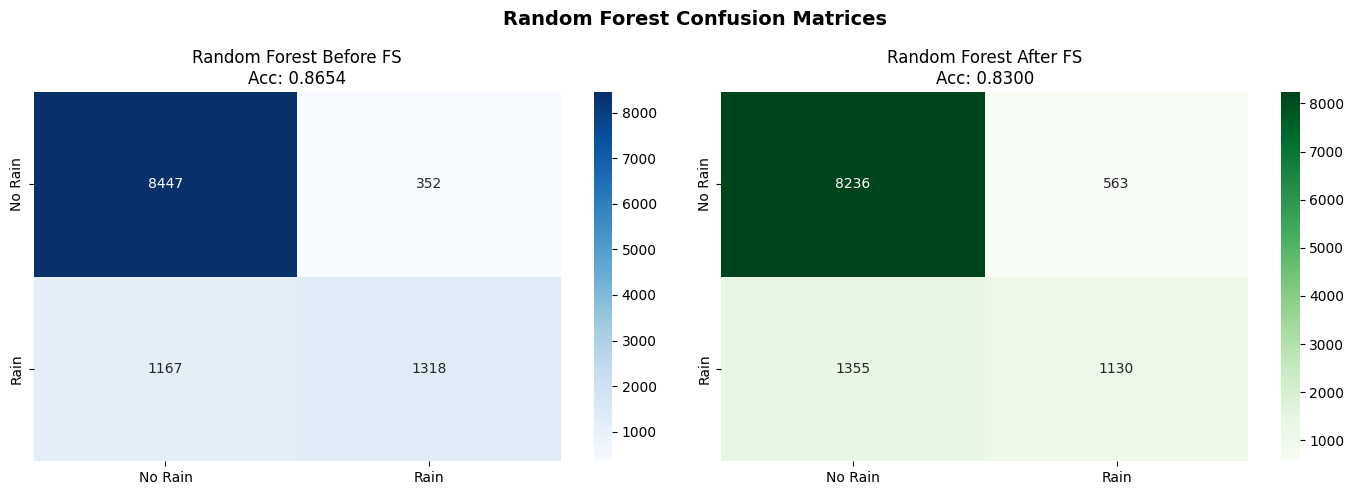

In [17]:
# ==================== VISUALIZATIONS ====================
print("\n[6] Generating visualizations...")

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Rain', 'Rain'],
            yticklabels=['No Rain', 'Rain'], ax=axes[0])
axes[0].set_title(f'Random Forest Before FS\nAcc: {accuracy_before:.4f}', fontsize=12)

sns.heatmap(cm_after, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Rain', 'Rain'],
            yticklabels=['No Rain', 'Rain'], ax=axes[1])
axes[1].set_title(f'Random Forest After FS\nAcc: {accuracy_after:.4f}', fontsize=12)

plt.suptitle('Random Forest Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rf_confusion_matrices.png', dpi=300)
plt.show()

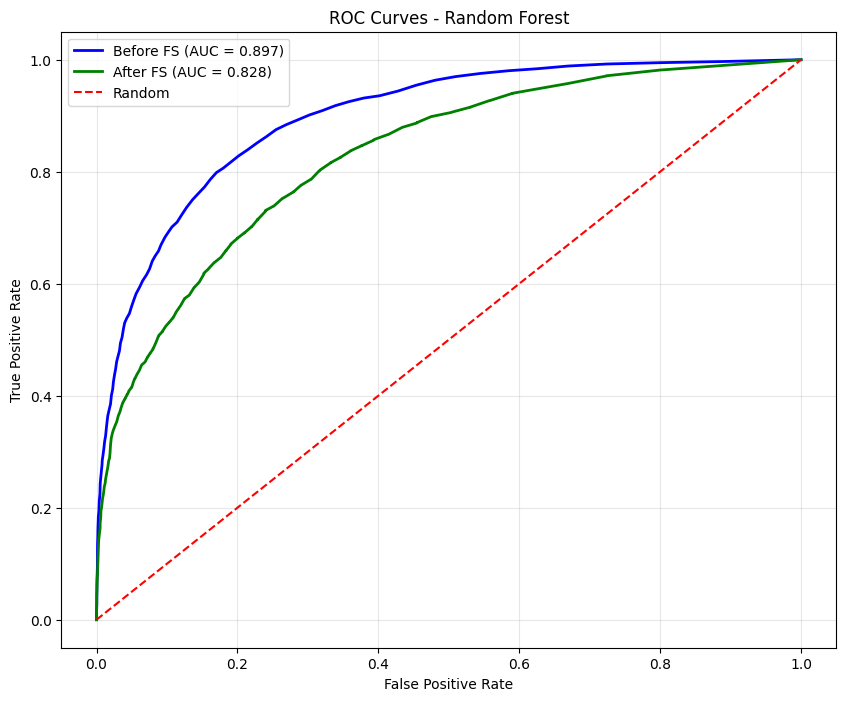

In [18]:
# ROC Curves
plt.figure(figsize=(10, 8))
fpr_before, tpr_before, _ = roc_curve(y_test, y_pred_proba_before)
fpr_after, tpr_after, _ = roc_curve(y_test, y_pred_proba_after)

plt.plot(fpr_before, tpr_before, 'b-', linewidth=2, label=f'Before FS (AUC = {auc_before:.3f})')
plt.plot(fpr_after, tpr_after, 'g-', linewidth=2, label=f'After FS (AUC = {auc_after:.3f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Random Forest')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('rf_roc_curves.png', dpi=300)
plt.show()

In [19]:
# ==================== SAVE RESULTS ====================
# Create summary table
summary_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'G-mean', 'AUC-ROC'],
    'Before FS (Ours)': [
        f"{accuracy_before:.4f}",
        f"{precision_before:.4f}",
        f"{recall_before:.4f}",
        f"{f1_before:.4f}",
        f"{gmean_before:.4f}",
        f"{auc_before:.4f}"
    ],
    'Before FS (Paper)': ['0.85', '0.82', '0.74', '0.74', '0.69', '0.70'],
    'After FS (Ours)': [
        f"{accuracy_after:.4f}",
        f"{precision_after:.4f}",
        f"{recall_after:.4f}",
        f"{f1_after:.4f}",
        f"{gmean_after:.4f}",
        f"{auc_after:.4f}"
    ],
    'After FS (Paper)': ['0.81', '0.80', '0.81', '0.79', '0.69', '0.70']
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*60)
print("FINAL SUMMARY TABLE")
print("="*60)
display(summary_df)


summary_df.to_csv('random_forest_results.csv', index=False)
print("\n✓ Results saved to 'random_forest_results.csv'")


with open('random_forest_results.txt', 'w') as f:
    f.write("RANDOM FOREST MODEL RESULTS (EXACT PAPER IMPLEMENTATION)\n")
    f.write("="*60 + "\n\n")
    f.write(f"Before Feature Selection:\n")
    f.write(f"  Accuracy:  {accuracy_before:.4f} (Paper: 0.85)\n")
    f.write(f"  Precision: {precision_before:.4f} (Paper: 0.82)\n")
    f.write(f"  Recall:    {recall_before:.4f} (Paper: 0.74)\n")
    f.write(f"  F1-Score:  {f1_before:.4f} (Paper: 0.74)\n")
    f.write(f"  G-mean:    {gmean_before:.4f} (Paper: 0.69)\n")
    f.write(f"  AUC-ROC:   {auc_before:.4f} (Paper: 0.70)\n\n")
    f.write(f"After Feature Selection:\n")
    f.write(f"  Accuracy:  {accuracy_after:.4f} (Paper: 0.81)\n")
    f.write(f"  Precision: {precision_after:.4f} (Paper: 0.80)\n")
    f.write(f"  Recall:    {recall_after:.4f} (Paper: 0.81)\n")
    f.write(f"  F1-Score:  {f1_after:.4f} (Paper: 0.79)\n")
    f.write(f"  G-mean:    {gmean_after:.4f} (Paper: 0.69)\n")
    f.write(f"  AUC-ROC:   {auc_after:.4f} (Paper: 0.70)\n")

print("\n" + "="*60)


FINAL SUMMARY TABLE


,Metric,Before FS (Ours),Before FS (Paper),After FS (Ours),After FS (Paper)
0,Accuracy,0.8654,0.85,0.8300,0.81
1,Precision,0.7892,0.82,0.6675,0.80
2,Recall,0.5304,0.74,0.4547,0.81
3,F1-Score,0.6344,0.74,0.5409,0.79
4,G-mean,0.7136,0.69,0.6524,0.69
5,AUC-ROC,0.8973,0.70,0.8281,0.70



✓ Results saved to 'random_forest_results.csv'

✓ ALL DONE! Results saved to files
